# Targeted regularization with 25 labelled images

**Stage 4 targeted experiments.** Notebook 04 identified large train–validation differences and rising late validation loss for both saved n=25 training-image selections. This report evaluates two predeclared interventions in sequence: stronger AdamW weight decay and mild whole-image brightness/contrast augmentation. Each block changes one factor against the same D4-only references, uses both subset selections and both initializations, and keeps the geographic test region locked.


## 1. Hypothesis and paired design

The hypothesis is that stronger parameter shrinkage may reduce overfitting and improve validation performance when only 25 labelled images are available. Each subset seed (17 and 29) and initialization (random and ImageNet) has a direct `1e-4` reference and a fresh `1e-2` run.

All runs use the same training IDs within a pair, model/data-order/augmentation seeds, EfficientNet-B0 U-Net, batch size 4, D4 augmentation, BCE–Dice objective, BatchNorm behavior, 4,000 updates and fixed learning-rate change from `1e-3` to `1e-4` after step 2,000. Biases and one-dimensional normalization parameters have zero decay. The primary metric is mean per-image roof IoU at threshold 0.5 on the shared 289-image validation region.

## 2. What AdamW weight decay changes

PyTorch AdamW applies decay separately from the gradient moment estimates: before the adaptive gradient update, a decayed parameter is multiplied by approximately `1 − learning_rate × weight_decay` at each step. It is therefore not an additional term in the BCE–Dice loss. Its cumulative magnitude depends on the decay coefficient, every applied learning rate and the number of updates ([PyTorch 2.8 AdamW documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.AdamW.html)).

The product below imagines zero gradients throughout training. It illustrates the scale of the direct shrinkage only; real weights also receive adaptive gradient updates, so the value does not predict actual weight norms or model performance.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = pd.read_csv(ROOT / 'reports/weight_decay_n25_results.csv')
EFFECTS = pd.read_csv(ROOT / 'reports/weight_decay_n25_effects.csv')

In [2]:
shrinkage = (RESULTS[[
    'weight_decay', 'shrinkage_factor_without_gradients',
]].drop_duplicates().sort_values('weight_decay'))
display(shrinkage.rename(columns={
    'weight_decay': 'weight decay',
    'shrinkage_factor_without_gradients': 'illustrative cumulative factor',
}).style.format({
    'weight decay': '{:.0e}', 'illustrative cumulative factor': '{:.6f}',
}))

,weight decay,illustrative cumulative factor
0,1e-04,0.999780
1,1e-02,0.978240


The illustrative factor is 0.999780 for `1e-4` and 0.978240 for `1e-2`. The latter is a materially stronger direct effect, but still acts only on the 92 multi-dimensional parameter tensors. The 151 bias and one-dimensional tensors remain in a zero-decay group.

## 3. Validation results and runtime

The selected checkpoint is the measured step with highest validation IoU; the step-4,000 endpoint is reported separately. Dice and average precision (AP) are computed for the selected checkpoint. Runtime includes optimization and scheduled validation.

In [3]:
columns = {
    'subset_seed': 'subset seed', 'initialization': 'initialization',
    'weight_decay': 'weight decay', 'best_step': 'best step',
    'best_validation_iou': 'best IoU', 'iou_step_4000': 'IoU at 4,000',
    'validation_loss_step_4000': 'loss at 4,000',
    'selected_validation_dice': 'Dice', 'selected_validation_ap': 'AP',
    'total_minutes': 'total min',
}
display(RESULTS[list(columns)].rename(columns=columns).style.format({
    'weight decay': '{:.0e}', 'best IoU': '{:.3f}', 'IoU at 4,000': '{:.3f}',
    'loss at 4,000': '{:.3f}', 'Dice': '{:.3f}', 'AP': '{:.3f}',
    'total min': '{:.1f}',
}))

,subset seed,initialization,weight decay,best step,best IoU,"IoU at 4,000","loss at 4,000",Dice,AP,total min
0,17,imagenet,1e-04,1700,0.837,0.828,0.165,0.906,0.948,23.8
1,17,imagenet,1e-02,2200,0.834,0.832,0.164,0.904,0.949,24.3
2,17,random,1e-04,2000,0.781,0.779,0.203,0.868,0.927,23.8
3,17,random,1e-02,3400,0.784,0.782,0.196,0.871,0.932,24.2
4,29,imagenet,1e-04,3000,0.842,0.840,0.156,0.908,0.959,24.0
5,29,imagenet,1e-02,3300,0.835,0.835,0.162,0.904,0.952,24.2
6,29,random,1e-04,2600,0.783,0.780,0.194,0.869,0.934,23.9
7,29,random,1e-02,3200,0.778,0.774,0.203,0.867,0.931,24.0


The four new runs required 77.3 minutes of optimization and 96.6 minutes including evaluation on MPS. Stronger decay does not improve all four pairs. Seed 17 Random rises from 0.781 to 0.784 best IoU, whereas Seed 29 Random falls from 0.783 to 0.778. Both ImageNet pairs have lower selected maxima under `1e-2`: 0.834 versus 0.837 for Seed 17 and 0.835 versus 0.842 for Seed 29.

## 4. Paired changes from `1e-4` to `1e-2`

Positive IoU, Dice and AP changes favor stronger decay; negative endpoint-loss changes favor it. A smaller train–validation gap is not sufficient evidence by itself because it could result from worse training fit. We therefore show the training-IoU change alongside the gap change.

In [4]:
effect_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'best_iou_change': 'best-IoU change',
    'endpoint_iou_change': 'endpoint-IoU change',
    'endpoint_validation_loss_change': 'endpoint-loss change',
    'selected_training_iou_change': 'training-IoU change',
    'selected_iou_gap_change': 'IoU-gap change',
    'selected_dice_change': 'Dice change', 'selected_ap_change': 'AP change',
}
display(EFFECTS[list(effect_columns)].rename(columns=effect_columns).style.format({
    column: '{:+.4f}' for column in list(effect_columns.values())[2:]
}))

,seed,initialization,best-IoU change,endpoint-IoU change,endpoint-loss change,training-IoU change,IoU-gap change,Dice change,AP change
0,17,imagenet,-0.0026,+0.0041,-0.0013,+0.0004,+0.0031,-0.0018,+0.0013
1,17,random,+0.0035,+0.0027,-0.0066,+0.0104,+0.0068,+0.0030,+0.0046
2,29,imagenet,-0.0063,-0.0048,+0.0056,+0.0012,+0.0075,-0.0041,-0.0077
3,29,random,-0.0049,-0.0068,+0.0092,+0.0065,+0.0114,-0.0025,-0.0030


The effect does not repeat across training-image selections. Seed 17 Random improves best IoU by +0.0035 and endpoint loss by −0.0066, but Seed 29 Random loses 0.0049 best IoU and has +0.0092 higher endpoint loss. ImageNet loses best IoU in both selections (−0.0026 and −0.0063). Dice and AP likewise show mixed Seed 17 changes and negative Seed 29 changes.

The selected train–validation IoU gap increases in all four pairs by +0.0031 to +0.0114 because the selected training IoU also increases. Stronger decay therefore does not reduce the diagnosed separation; the models fit the small training subsets at least as closely while validation improvements fail to repeat.

## 5. Learning curves and late behavior

The paired curves below use the same axes within each metric. Grey denotes the `1e-4` reference, green denotes `1e-2`, and the vertical line marks the learning-rate reduction after step 2,000.

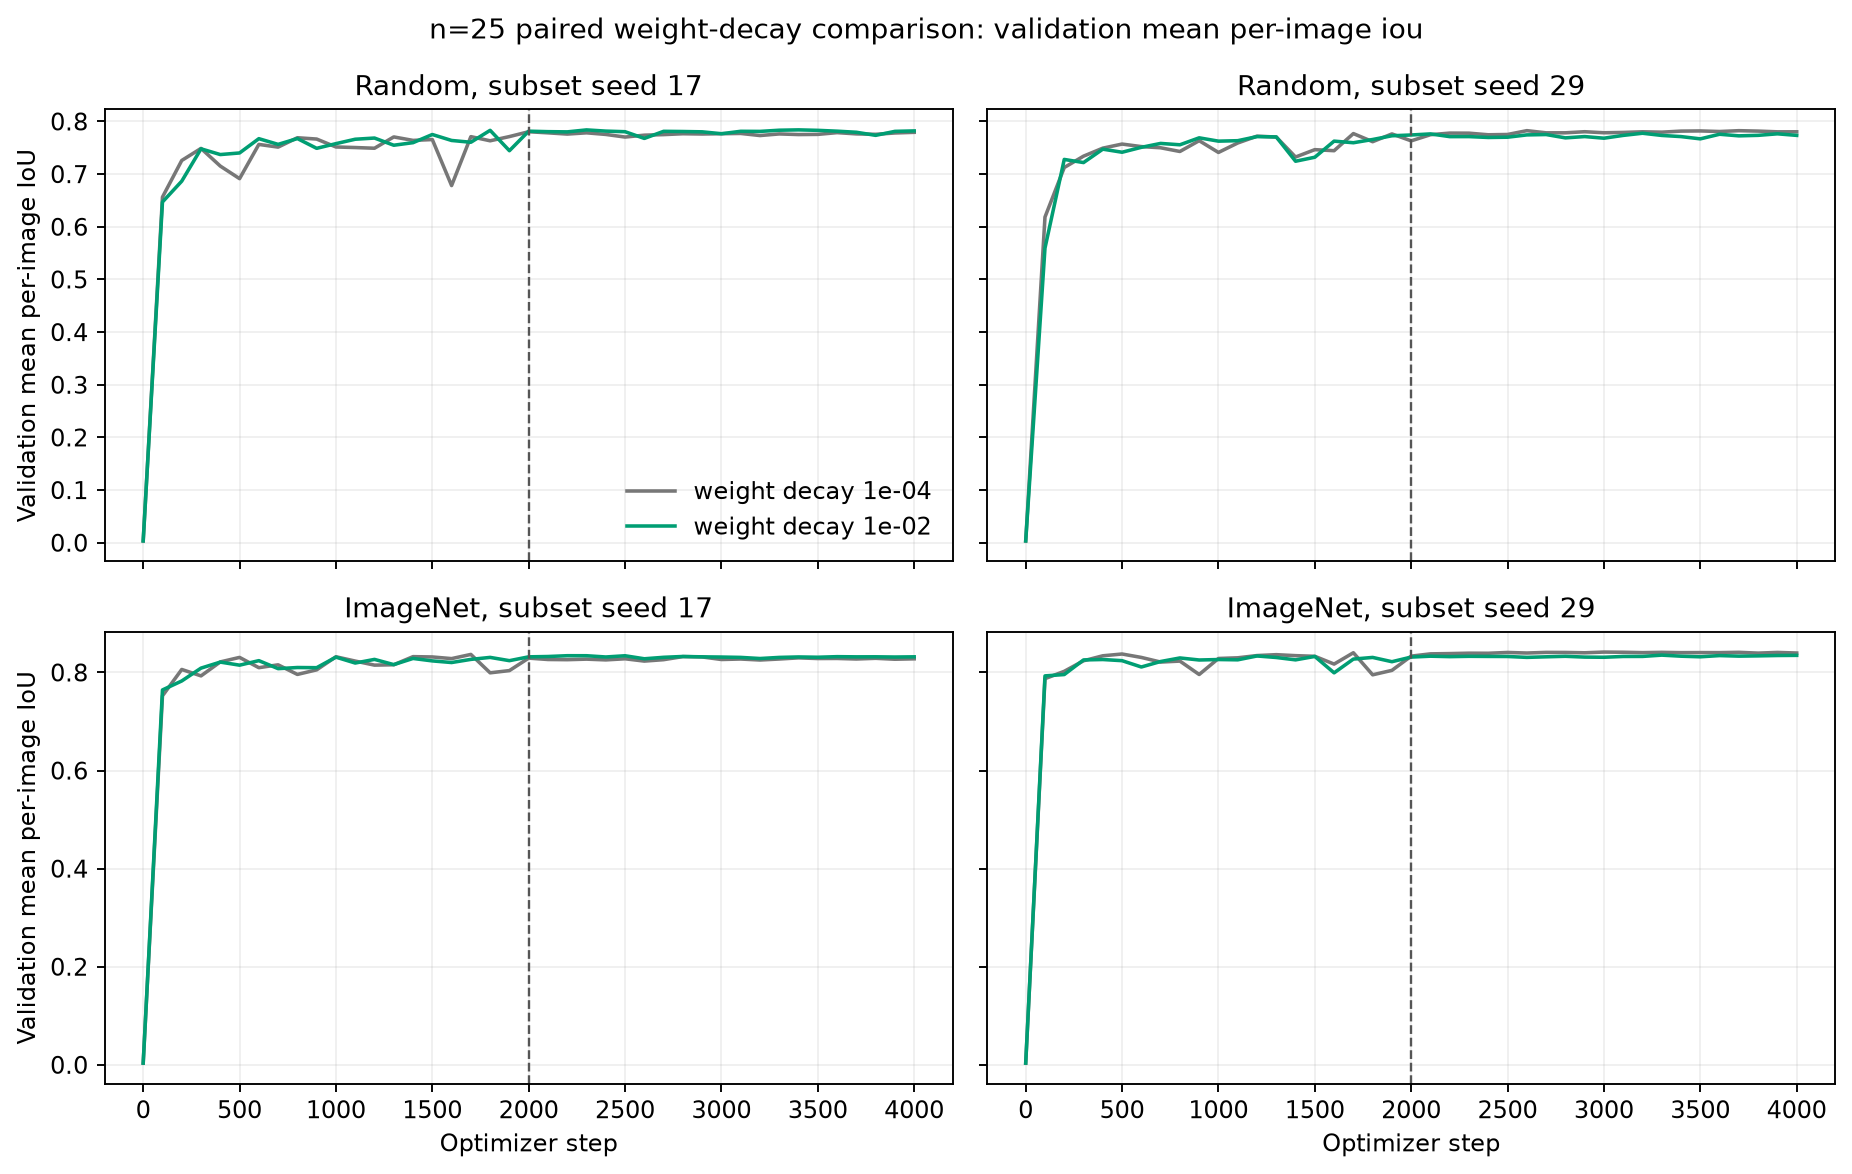

In [5]:
display(Image(filename=ROOT / 'reports/figures/weight_decay_n25_iou.png'))

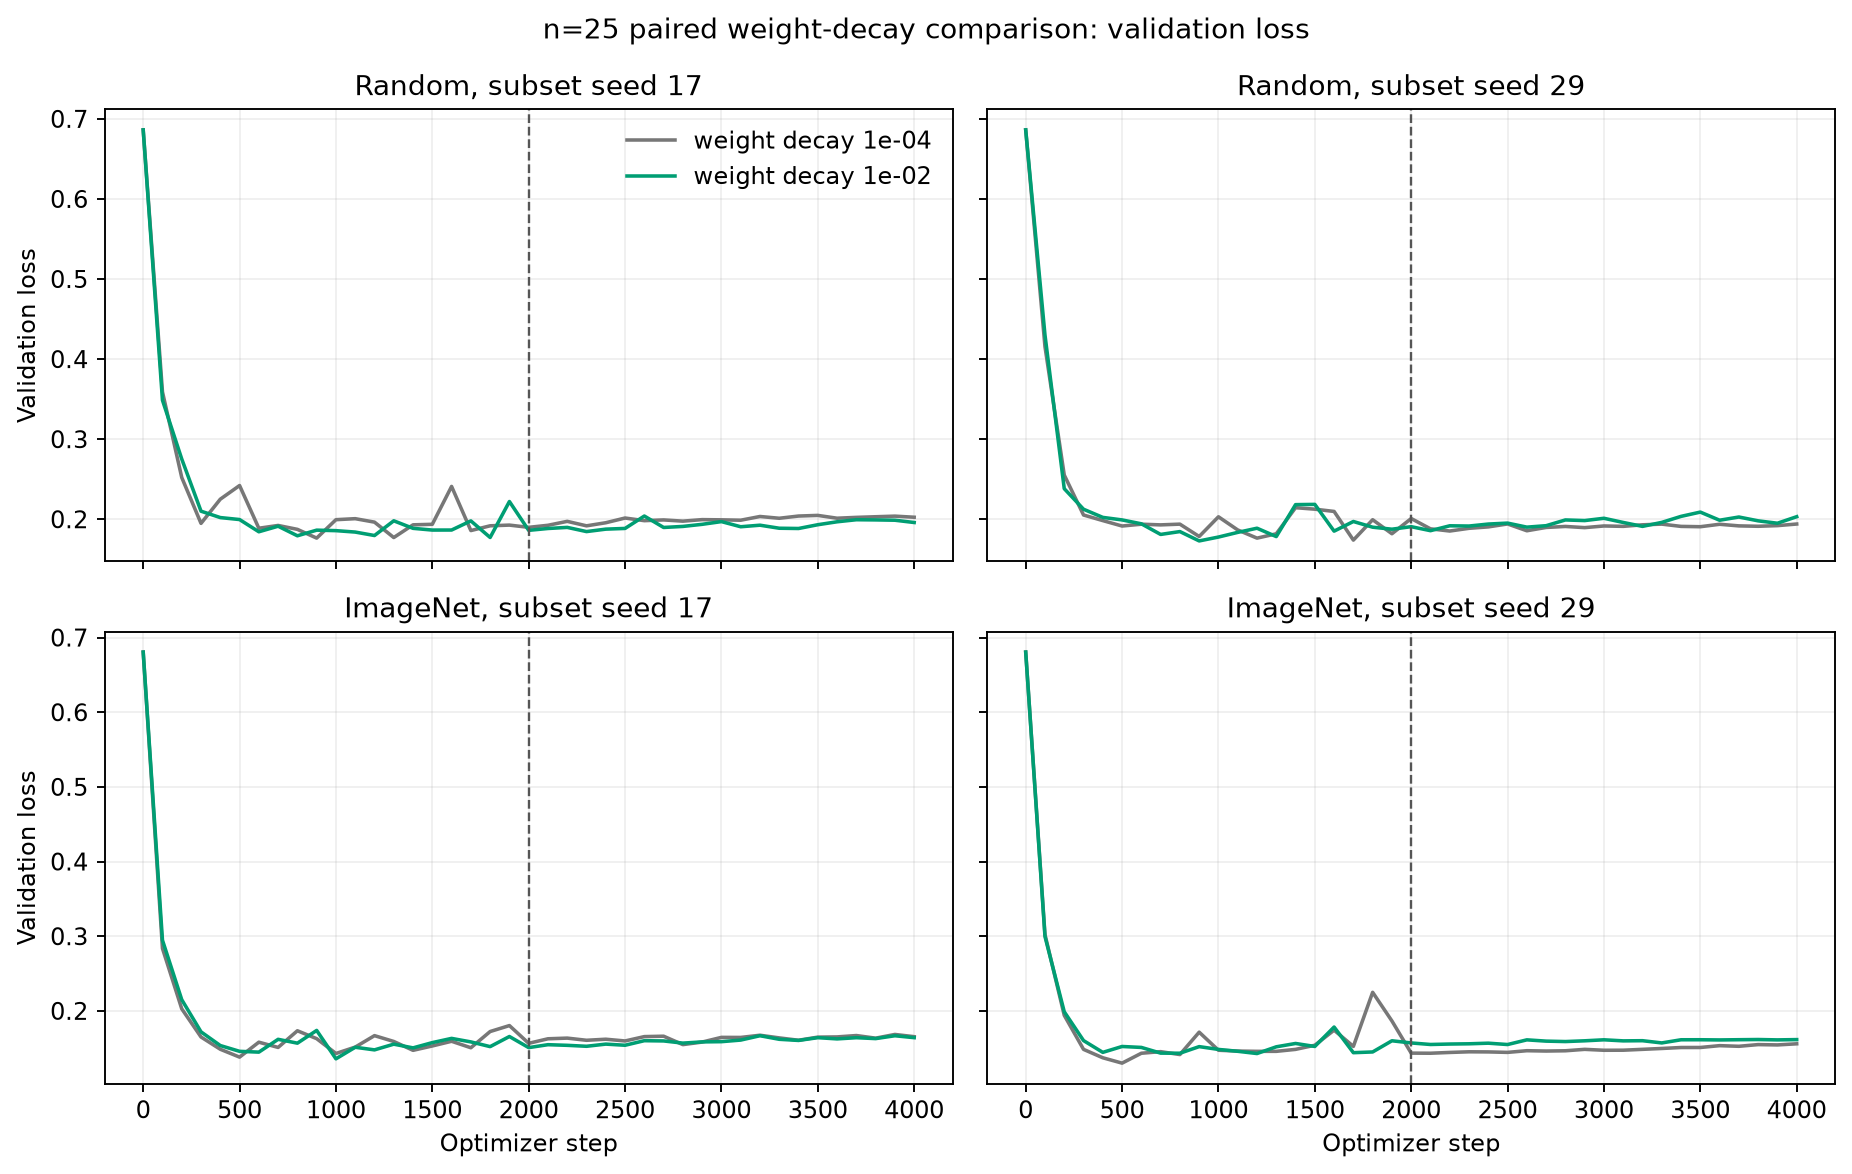

In [6]:
display(Image(filename=ROOT / 'reports/figures/weight_decay_n25_loss.png'))

The curves confirm that the result is not explained by one isolated selected checkpoint. Strong decay lowers Seed 17 Random loss late, but Seed 29 Random loss is higher. Both ImageNet strong-decay curves remain at or below their references in IoU. All four configurations still show positive late validation-loss trends, so `1e-2` does not remove the small-data overfitting pattern.

In [7]:
late_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'weight_decay': 'weight decay',
    'iou_trend_per_1000': 'IoU trend / 1,000',
    'iou_residual_sd': 'IoU residual SD',
    'loss_trend_per_1000': 'loss trend / 1,000',
    'loss_residual_sd': 'loss residual SD',
}
display(RESULTS[list(late_columns)].rename(columns=late_columns).style.format({
    'weight decay': '{:.0e}', 'IoU trend / 1,000': '{:+.4f}',
    'IoU residual SD': '{:.4f}', 'loss trend / 1,000': '{:+.4f}',
    'loss residual SD': '{:.4f}',
}))

,seed,initialization,weight decay,"IoU trend / 1,000",IoU residual SD,"loss trend / 1,000",loss residual SD
0,17,imagenet,1e-04,+0.0010,0.0020,+0.0025,0.0029
1,17,imagenet,1e-02,-0.0007,0.0015,+0.0064,0.0020
2,17,random,1e-04,+0.0009,0.0020,+0.0051,0.0020
3,17,random,1e-02,+0.0004,0.0037,+0.0047,0.0041
4,29,imagenet,1e-04,+0.0008,0.0008,+0.0063,0.0009
5,29,imagenet,1e-02,+0.0011,0.0010,+0.0033,0.0014
6,29,random,1e-04,+0.0030,0.0016,+0.0027,0.0019
7,29,random,1e-02,+0.0010,0.0028,+0.0064,0.0040


Late stability also changes inconsistently. IoU residual standard deviation falls for Seed 17 ImageNet but rises for the other three pairs. Validation-loss trend improves for Seed 17 Random and Seed 29 ImageNet, while worsening for Seed 17 ImageNet and Seed 29 Random. A smoother curve in one pair therefore does not support a general benefit.

## 6. Comparable training and validation evaluation

Training metrics are recomputed at each selected checkpoint with augmentation disabled and evaluation mode enabled, matching validation preprocessing and model mode. This avoids comparing the augmented training objective directly with deterministic validation loss.

In [8]:
comparison_columns = {
    'subset_seed': 'seed', 'initialization': 'init', 'weight_decay': 'weight decay',
    'selected_training_loss': 'train loss',
    'selected_validation_loss': 'validation loss',
    'selected_training_iou': 'train IoU',
    'best_validation_iou': 'validation IoU',
    'training_minus_validation_iou': 'IoU gap',
    'selected_training_dice': 'train Dice',
    'selected_validation_dice': 'validation Dice',
    'selected_training_ap': 'train AP', 'selected_validation_ap': 'validation AP',
}
display(RESULTS[list(comparison_columns)].rename(columns=comparison_columns).style.format({
    'weight decay': '{:.0e}',
    **{column: '{:.3f}' for column in list(comparison_columns.values())[3:]},
}))

,seed,init,weight decay,train loss,validation loss,train IoU,validation IoU,IoU gap,train Dice,validation Dice,train AP,validation AP
0,17,imagenet,1e-04,0.020,0.151,0.967,0.837,0.130,0.983,0.906,0.999,0.948
1,17,imagenet,1e-02,0.019,0.154,0.967,0.834,0.133,0.983,0.904,0.999,0.949
2,17,random,1e-04,0.047,0.190,0.922,0.781,0.141,0.959,0.868,0.992,0.927
3,17,random,1e-02,0.039,0.188,0.932,0.784,0.148,0.964,0.871,0.994,0.932
4,29,imagenet,1e-04,0.017,0.147,0.972,0.842,0.130,0.986,0.908,0.999,0.959
5,29,imagenet,1e-02,0.016,0.157,0.973,0.835,0.137,0.986,0.904,0.999,0.952
6,29,random,1e-04,0.039,0.186,0.935,0.783,0.153,0.966,0.869,0.995,0.934
7,29,random,1e-02,0.035,0.191,0.942,0.778,0.164,0.970,0.867,0.996,0.931


## 7. Limitations and decision

This is a targeted validation experiment with two partially overlapping training subsets and one repeatedly used validation region. All non-subset random seeds are fixed, so it isolates the configured decay change but does not measure full training variance. Adjacent checkpoints are dependent, and two subset selections do not justify confidence intervals, significance claims or geographic generalization claims. The test region was absent from training, checkpoint selection and qualitative analysis.

The evidence does not support adopting `weight_decay=1e-2` for the n=25 recipe: the best-IoU effect is negative in three of four pairs, both ImageNet pairs worsen, Seed 29 worsens for both initializations, and the train–validation gap increases everywhere. This does not show that AdamW weight decay is generally ineffective; it shows that this predeclared strength is not robustly beneficial under the tested schedule.

The next most informative limited experiment is mild brightness/contrast augmentation at n=25, paired against the existing D4-only references across both subset selections and initializations. It directly targets limited appearance diversity rather than increasing parameter shrinkage. Its range and application order should be predeclared before execution. No follow-up experiment is run here.

## 8. Weight-decay conclusion

Increasing AdamW weight decay from `1e-4` to `1e-2` produces one small favorable result for Seed 17 Random but fails to repeat across the second training-image selection or the pretrained models. It neither reduces the comparable train–validation gap nor consistently improves late loss and stability. The current `1e-4` recipe remains the reference for the colour experiment.


## 9. Mild brightness and contrast: question and method

The second experiment asks whether mild appearance diversity reduces the n=25 generalization gap. Every occurrence of a training image receives two independent factors drawn from `Uniform(0.85, 1.15)` with a dedicated seed of 1703. Torchvision applies whole-image RGB brightness first and contrast second to float32 values in `[0, 1]`; its tensor operations clip results to the valid range. D4 remains aligned between image and mask, while colour changes never touch the mask. ImageNet normalization follows all augmentation.

Random and ImageNet runs within each subset use identical training IDs, batch order, D4 codes and colour-factor sequence. Model, data-order and D4 seeds are unchanged. Validation and selected-checkpoint training evaluation use original-orientation images without random augmentation. The recipe otherwise remains the accepted `weight_decay=1e-4`, 4,000-update schedule. The implementation follows the documented tensor semantics of [torchvision brightness](https://docs.pytorch.org/vision/0.23/generated/torchvision.transforms.functional.adjust_brightness.html) and [contrast](https://docs.pytorch.org/vision/0.23/generated/torchvision.transforms.functional.adjust_contrast.html).


In [9]:
PHOTO_RESULTS = pd.read_csv(ROOT / 'reports/photometric_n25_results.csv')
PHOTO_EFFECTS = pd.read_csv(ROOT / 'reports/photometric_n25_effects.csv')


The fixed preview below shows the original images and both joint boundary settings. These extremes are visibly different but retain the scene content and geometry; intermediate factors are drawn independently, so brightness and contrast need not move in the same direction.


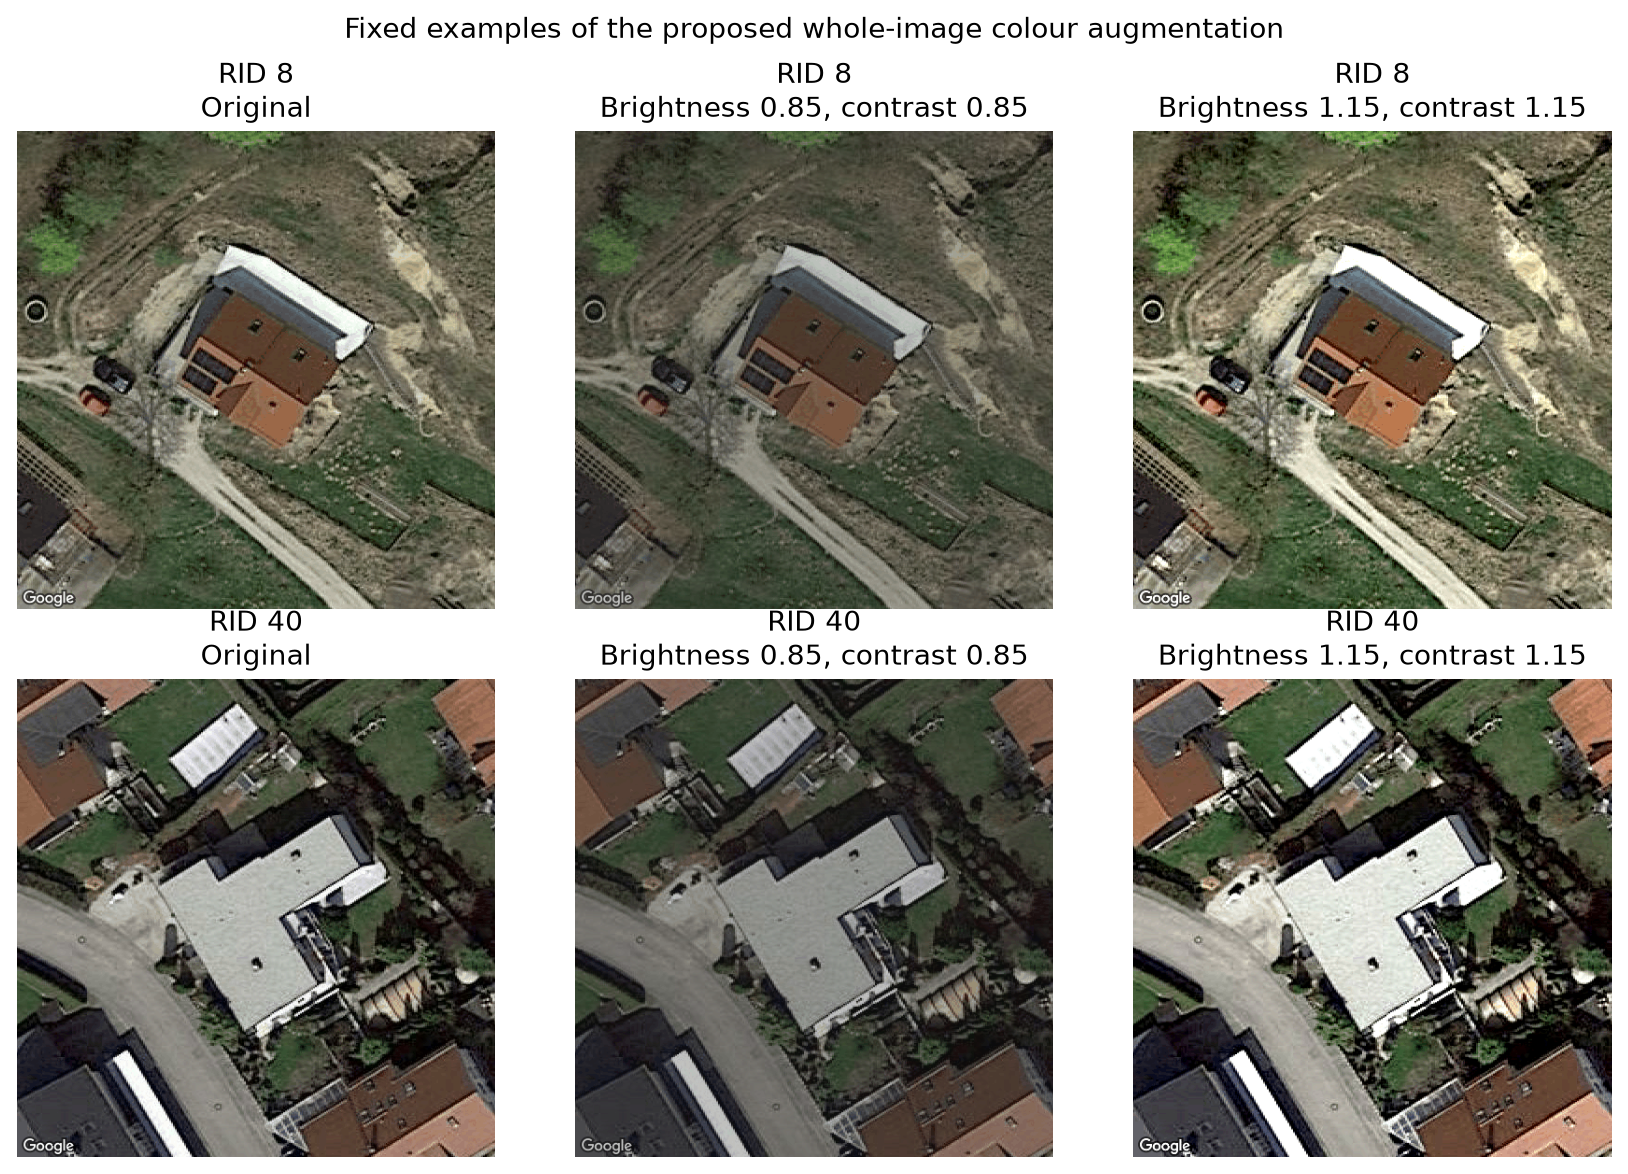

In [10]:
display(Image(filename=ROOT / 'reports/figures/photometric_n25_examples.png'))


## 10. Validation results and paired effects

The table reports the same selected-checkpoint and endpoint measures as the weight-decay block. The four new runs processed 14,287 examples each, equivalent to 571.48 passages through their 25-image subsets. Their combined optimization time was 91.7 minutes and total time including scheduled evaluation was 113.1 minutes on MPS.


In [11]:
photo_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'photometric_augmentation': 'brightness + contrast',
    'best_step': 'best step', 'best_validation_iou': 'best IoU',
    'iou_step_4000': 'IoU at 4,000',
    'validation_loss_step_4000': 'loss at 4,000',
    'selected_validation_dice': 'Dice', 'selected_validation_ap': 'AP',
    'total_minutes': 'total min',
}
display(PHOTO_RESULTS[list(photo_columns)].rename(columns=photo_columns).style.format({
    'best IoU': '{:.3f}', 'IoU at 4,000': '{:.3f}',
    'loss at 4,000': '{:.3f}', 'Dice': '{:.3f}', 'AP': '{:.3f}',
    'total min': '{:.1f}',
}))


,seed,initialization,brightness + contrast,best step,best IoU,"IoU at 4,000","loss at 4,000",Dice,AP,total min
0,17,imagenet,False,1700,0.837,0.828,0.165,0.906,0.948,23.8
1,17,imagenet,True,1700,0.830,0.822,0.169,0.901,0.948,37.6
2,17,random,False,2000,0.781,0.779,0.203,0.868,0.927,23.8
3,17,random,True,3600,0.788,0.783,0.195,0.872,0.937,24.4
4,29,imagenet,False,3000,0.842,0.840,0.156,0.908,0.959,24.0
5,29,imagenet,True,3900,0.841,0.839,0.155,0.908,0.955,26.1
6,29,random,False,2600,0.783,0.780,0.194,0.869,0.934,23.9
7,29,random,True,3100,0.790,0.788,0.192,0.873,0.933,25.0


The direction depends on initialization. Mild colour augmentation improves Random best IoU for both subset selections: from 0.781 to 0.788 for Seed 17 and from 0.783 to 0.790 for Seed 29. It lowers the corresponding endpoint loss by 0.0080 and 0.0024. ImageNet does not repeat this gain: best IoU changes from 0.837 to 0.830 for Seed 17 and from 0.842 to 0.841 for Seed 29.


In [12]:
photo_effect_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'best_iou_change': 'best-IoU change',
    'endpoint_iou_change': 'endpoint-IoU change',
    'endpoint_validation_loss_change': 'endpoint-loss change',
    'selected_iou_gap_change': 'IoU-gap change',
    'selected_dice_change': 'Dice change', 'selected_ap_change': 'AP change',
}
display(PHOTO_EFFECTS[list(photo_effect_columns)].rename(columns=photo_effect_columns).style.format({
    column: '{:+.4f}' for column in list(photo_effect_columns.values())[2:]
}))


,seed,initialization,best-IoU change,endpoint-IoU change,endpoint-loss change,IoU-gap change,Dice change,AP change
0,17,imagenet,-0.0071,-0.0056,+0.0037,+0.0055,-0.0050,+0.0000
1,17,random,+0.0076,+0.0039,-0.0080,+0.0046,+0.0048,+0.0092
2,29,imagenet,-0.0007,-0.0004,-0.0008,+0.0049,+0.0001,-0.0045
3,29,random,+0.0074,+0.0077,-0.0024,+0.0012,+0.0039,-0.0004


The paired Random best-IoU effects are +0.0076 and +0.0074, a consistent descriptive result across the two image selections. The ImageNet effects are −0.0071 and −0.0007. Secondary metrics are mixed: Random Dice improves in both repetitions, whereas AP improves only for Seed 17; ImageNet AP is nearly unchanged for Seed 17 and lower for Seed 29. This pattern does not support one common augmentation benefit for both initialization strategies.


## 11. Learning curves and late behavior

Grey denotes the unchanged D4 reference and blue denotes D4 plus brightness/contrast. The dashed line marks the learning-rate reduction after step 2,000. The curves show every scheduled validation measurement, so the selected maxima can be assessed alongside endpoints and trajectory shape.


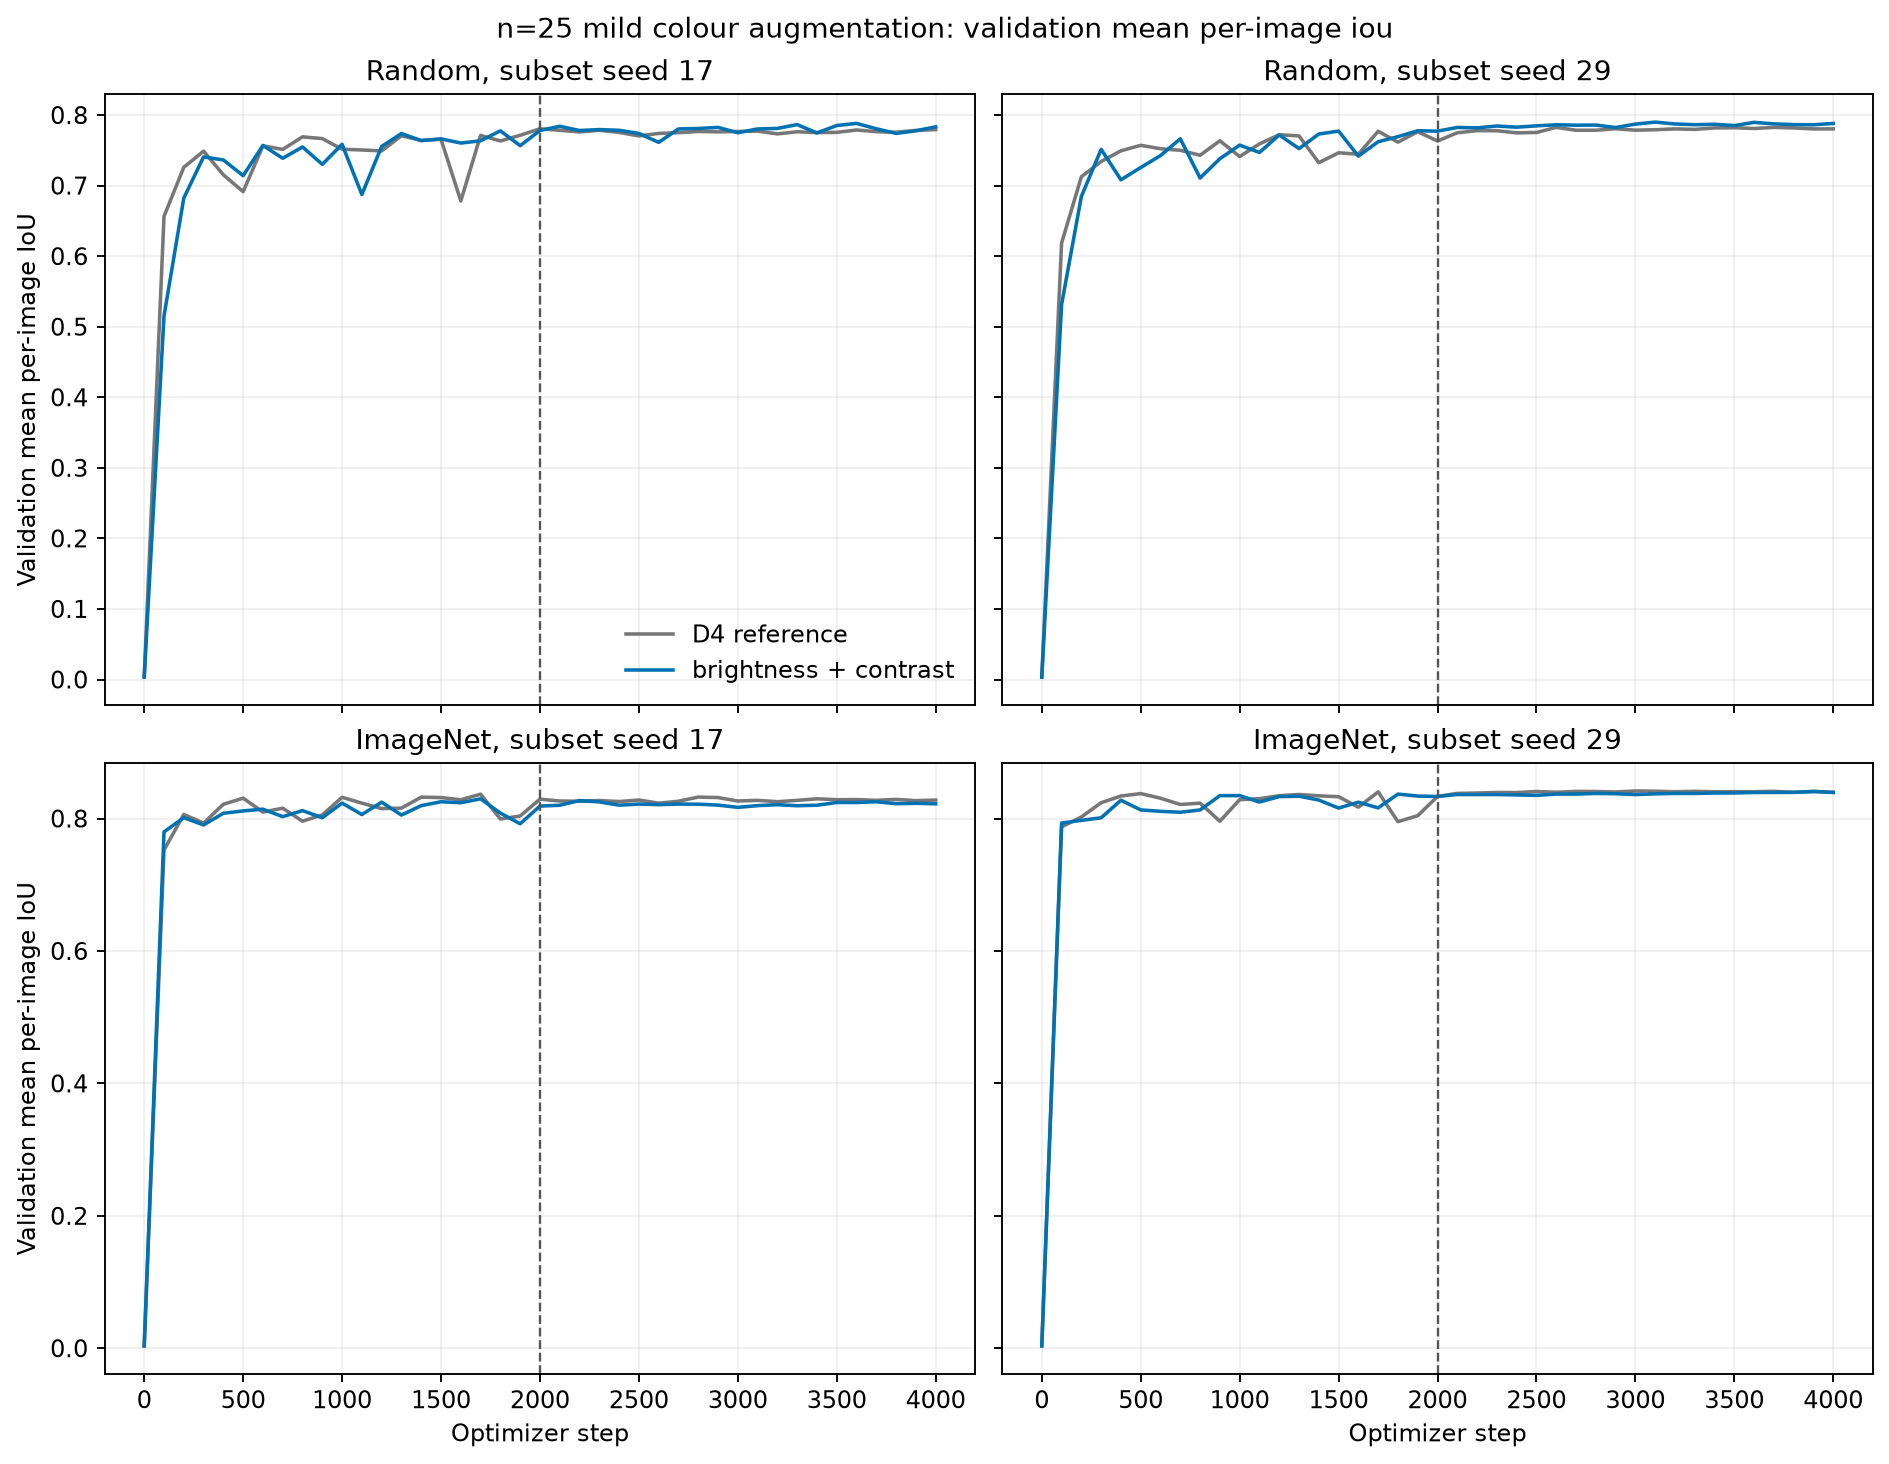

In [13]:
display(Image(filename=ROOT / 'reports/figures/photometric_n25_iou.png'))


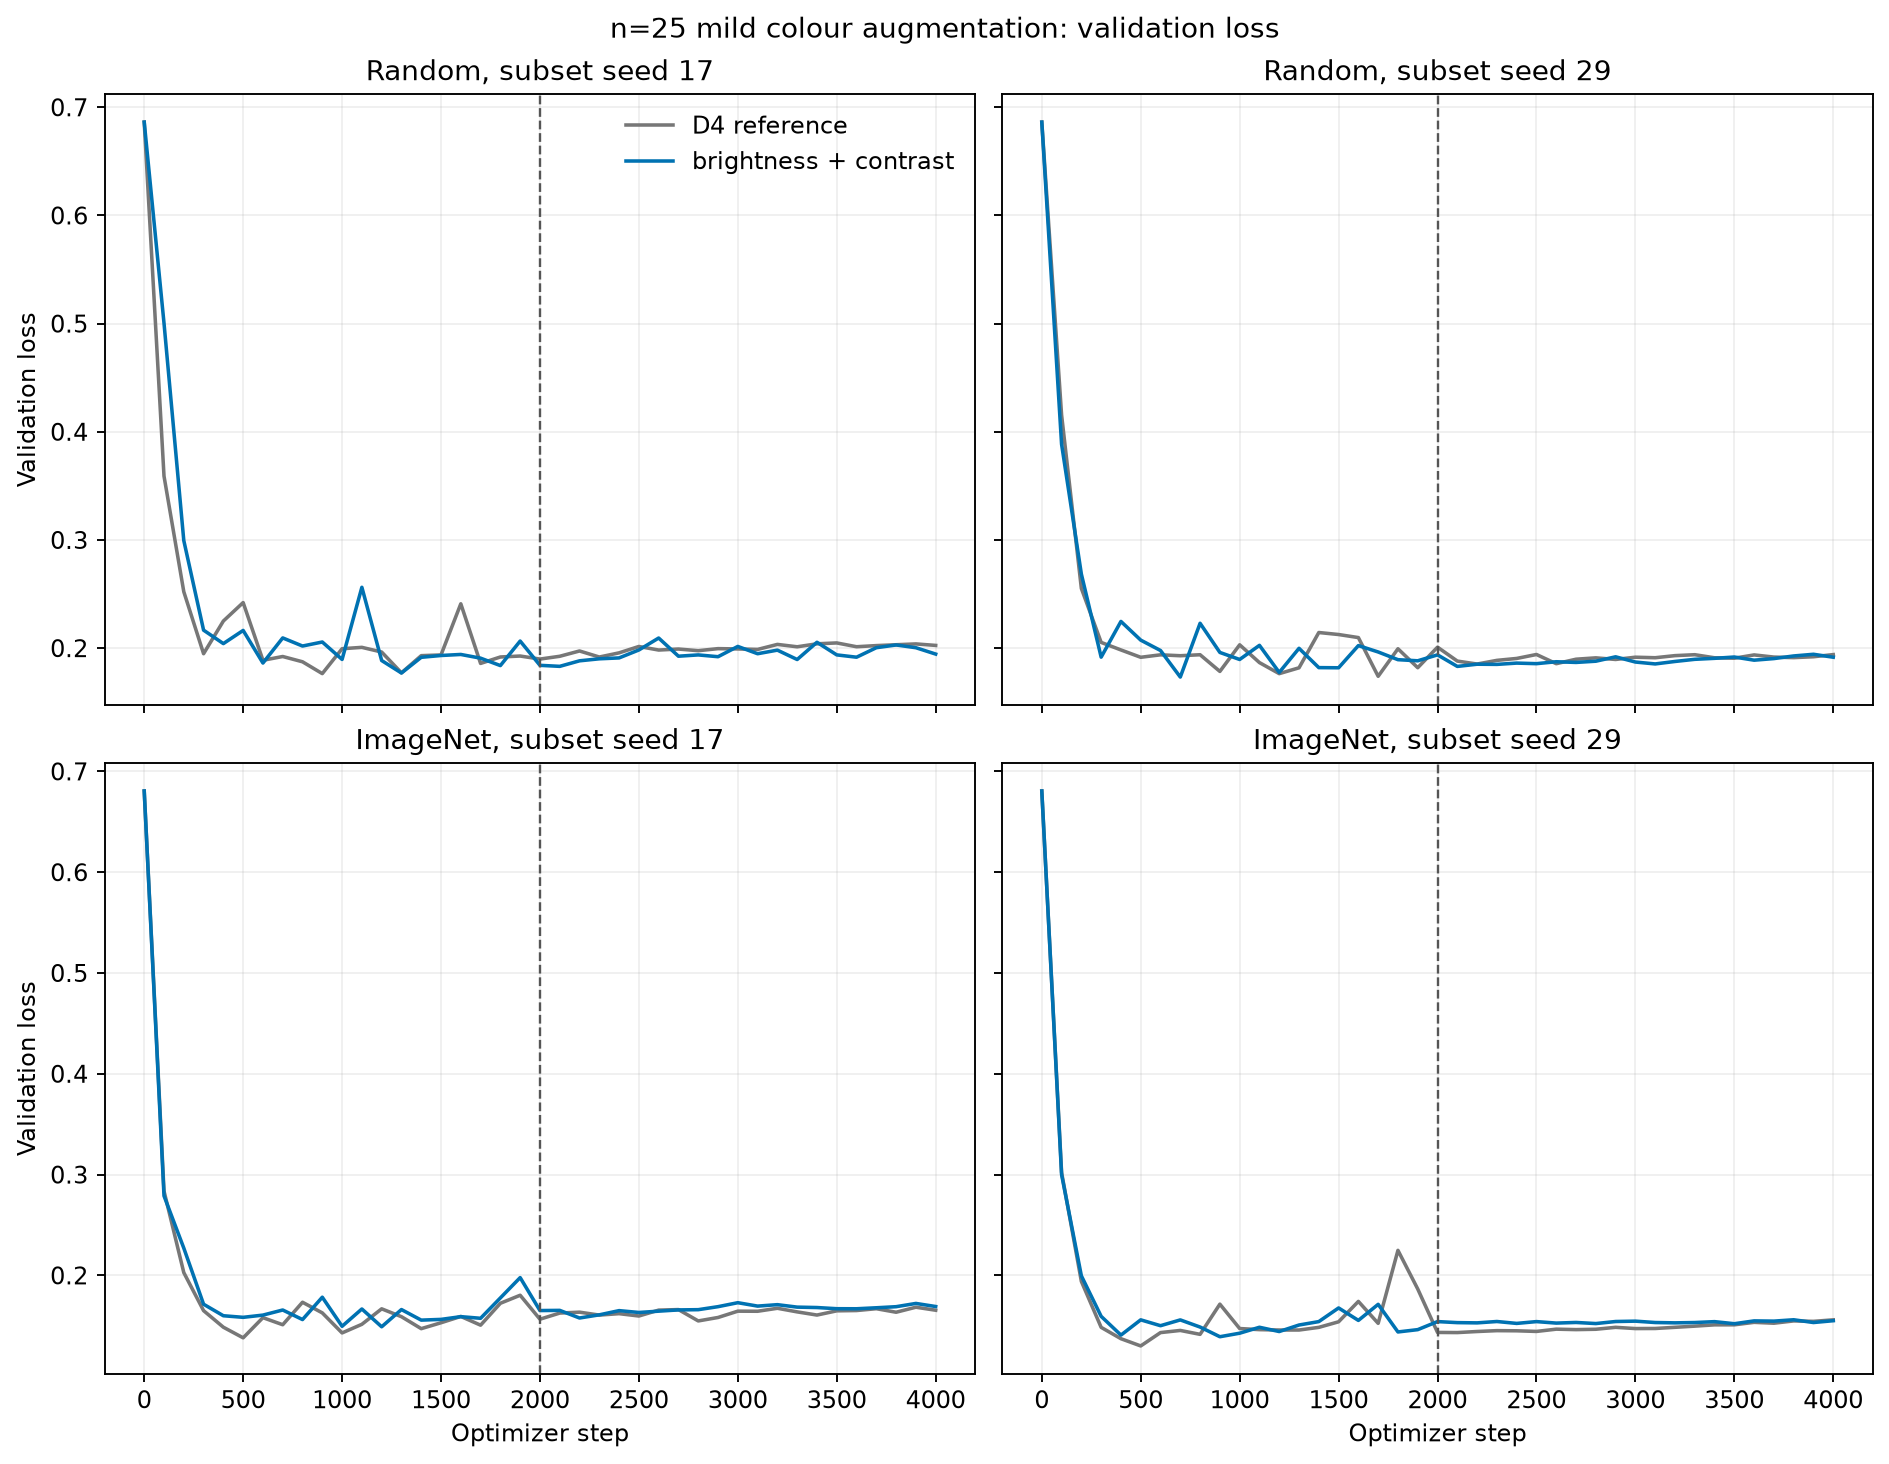

In [14]:
display(Image(filename=ROOT / 'reports/figures/photometric_n25_loss.png'))


In [15]:
photo_late_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'photometric_augmentation': 'brightness + contrast',
    'iou_trend_per_1000': 'IoU trend / 1,000',
    'iou_residual_sd': 'IoU residual SD',
    'loss_trend_per_1000': 'loss trend / 1,000',
    'loss_residual_sd': 'loss residual SD',
}
display(PHOTO_RESULTS[list(photo_late_columns)].rename(columns=photo_late_columns).style.format({
    'IoU trend / 1,000': '{:+.4f}', 'IoU residual SD': '{:.4f}',
    'loss trend / 1,000': '{:+.4f}', 'loss residual SD': '{:.4f}',
}))


,seed,initialization,brightness + contrast,"IoU trend / 1,000",IoU residual SD,"loss trend / 1,000",loss residual SD
0,17,imagenet,False,+0.0010,0.0020,+0.0025,0.0029
1,17,imagenet,True,+0.0003,0.0024,+0.0043,0.0026
2,17,random,False,+0.0009,0.0020,+0.0051,0.0020
3,17,random,True,+0.0022,0.0056,+0.0045,0.0057
4,29,imagenet,False,+0.0008,0.0008,+0.0063,0.0009
5,29,imagenet,True,+0.0024,0.0006,+0.0008,0.0009
6,29,random,False,+0.0030,0.0016,+0.0027,0.0019
7,29,random,True,+0.0026,0.0016,+0.0044,0.0016


Both augmented Random curves improve late, but Seed 17 has greater residual variation than its reference while Seed 29 is essentially unchanged. The augmented ImageNet Seed 17 curve stays below its reference and has a steeper rising late loss; Seed 29 finishes close to its reference with low residual variation. Thus the repeated Random gain is supported by endpoints and late means, while stability itself does not improve consistently.


## 12. Comparable training fit, limitations and decision

The next table uses augmentation-off evaluation in model evaluation mode for both training and validation images. The logged training loss during optimization includes random colour transforms and is not directly comparable with deterministic validation loss.


In [16]:
photo_comparison_columns = {
    'subset_seed': 'seed', 'initialization': 'init',
    'photometric_augmentation': 'brightness + contrast',
    'selected_training_loss': 'train loss',
    'selected_validation_loss': 'validation loss',
    'selected_training_iou': 'train IoU',
    'best_validation_iou': 'validation IoU',
    'training_minus_validation_iou': 'IoU gap',
    'selected_training_dice': 'train Dice',
    'selected_validation_dice': 'validation Dice',
    'selected_training_ap': 'train AP',
    'selected_validation_ap': 'validation AP',
}
display(PHOTO_RESULTS[list(photo_comparison_columns)].rename(columns=photo_comparison_columns).style.format({
    column: '{:.3f}' for column in list(photo_comparison_columns.values())[3:]
}))


,seed,init,brightness + contrast,train loss,validation loss,train IoU,validation IoU,IoU gap,train Dice,validation Dice,train AP,validation AP
0,17,imagenet,False,0.020,0.151,0.967,0.837,0.130,0.983,0.906,0.999,0.948
1,17,imagenet,True,0.021,0.157,0.965,0.830,0.135,0.982,0.901,0.999,0.948
2,17,random,False,0.047,0.190,0.922,0.781,0.141,0.959,0.868,0.992,0.927
3,17,random,True,0.039,0.192,0.934,0.788,0.146,0.965,0.872,0.995,0.937
4,29,imagenet,False,0.017,0.147,0.972,0.842,0.130,0.986,0.908,0.999,0.959
5,29,imagenet,True,0.015,0.153,0.976,0.841,0.135,0.988,0.908,0.999,0.955
6,29,random,False,0.039,0.186,0.935,0.783,0.153,0.966,0.869,0.995,0.934
7,29,random,True,0.033,0.185,0.944,0.790,0.154,0.971,0.873,0.996,0.933


The selected train–validation IoU gap increases slightly in all four pairs (+0.0012 to +0.0055), even though Random validation IoU improves. Mild colour variation therefore does not resolve the diagnosed separation. It may regularize features useful to randomly initialized models without limiting their fit to these 25 images, while the pretrained encoder may already provide adequate appearance invariance; this is an interpretation, not a directly measured mechanism.

Only training-image selection varies between the two repetitions; model, ordering and augmentation seeds are fixed, and the two 25-image subsets share four IDs. Both use the same repeatedly inspected validation region. Two partially overlapping selections do not measure full training variance and cannot justify significance or geographic-generalization claims. Checkpoint selection adds validation-selection bias. The locked test region remained absent from training, selection and qualitative inspection.

The evidence supports brightness/contrast as a promising Random-only option at n=25, but not as a shared replacement recipe: the gains are small, the training gap does not shrink, and ImageNet does not benefit. This result motivated the separately predeclared encoder-BatchNorm block below. The colour-augmentation runs are not used as its references and the interventions are not combined.


## 13. Colour-augmentation conclusion

At n=25, increasing weight decay to `1e-2` is not supported and remains rejected. Mild brightness/contrast augmentation produces a repeatable improvement of about +0.0075 best validation IoU for Random initialization across the two saved image selections, but no improvement for ImageNet initialization. Neither intervention reduces the comparable train–validation IoU gap. The D4-only, `weight_decay=1e-4` recipe therefore remains the reference for the BatchNorm experiment.


## 14. Fixed ImageNet BatchNorm statistics: question and method

The third targeted experiment asks whether preserving the pretrained encoder's BatchNorm statistics improves ImageNet fine-tuning with batches of four and only 25 labelled images. This is a motivated test, not evidence that BatchNorm caused earlier results or explains the colour-augmentation response.

A BatchNorm layer has non-trainable running mean and variance buffers and, when `affine=True`, trainable scale (`gamma`) and shift (`beta`) parameters. In the reference runs, encoder and decoder BatchNorm layers use batch statistics during training and update their running buffers. In the new variant, only encoder `BatchNorm2d` layers remain in evaluation mode after every `model.train()` call. They therefore normalize training activations with their original ImageNet running statistics and do not update `running_mean`, `running_var` or `num_batches_tracked`. Their affine parameters, all other encoder weights and the full decoder remain trainable; decoder BatchNorm continues to update, and Stochastic Depth remains in training mode.

This changes the normalization used by every training forward pass; it does more than prevent new statistics from being saved. Evaluation mode is separate from gradient control, so the encoder BatchNorm affine parameters still participate in autograd. These semantics follow the [PyTorch 2.8 BatchNorm2d documentation](https://docs.pytorch.org/docs/2.8/generated/torch.nn.BatchNorm2d.html) and its explanation of [evaluation mode versus autograd](https://docs.pytorch.org/docs/2.8/notes/autograd.html#evaluation-mode-nn-module-eval).

Both fresh ImageNet runs retain D4-only augmentation, baseline `weight_decay=1e-4`, exact training IDs and seeds, 4,000 updates and the fixed learning-rate change. The paired references update all BatchNorm statistics normally. No Random model, colour augmentation or test image is part of this block.


In [17]:
BN_RESULTS = pd.read_csv(ROOT / 'reports/encoder_batch_norm_n25_results.csv')
BN_EFFECTS = pd.read_csv(ROOT / 'reports/encoder_batch_norm_n25_effects.csv')


## 15. Validation results and paired effects

The two new runs processed 14,287 examples each, equivalent to 571.48 passages through their 25-image subsets. Together they required 36.7 minutes of optimization and 46.1 minutes including scheduled validation on MPS.


In [18]:
bn_columns = {
    'subset_seed': 'seed',
    'frozen_encoder_statistics': 'fixed ImageNet statistics',
    'best_step': 'best step', 'best_validation_iou': 'best IoU',
    'iou_step_4000': 'IoU at 4,000',
    'validation_loss_step_4000': 'loss at 4,000',
    'selected_validation_dice': 'Dice', 'selected_validation_ap': 'AP',
    'total_minutes': 'total min',
}
display(BN_RESULTS[list(bn_columns)].rename(columns=bn_columns).style.format({
    'best IoU': '{:.3f}', 'IoU at 4,000': '{:.3f}',
    'loss at 4,000': '{:.3f}', 'Dice': '{:.3f}', 'AP': '{:.3f}',
    'total min': '{:.1f}',
}))


,seed,fixed ImageNet statistics,best step,best IoU,"IoU at 4,000","loss at 4,000",Dice,AP,total min
0,17,False,1700,0.837,0.828,0.165,0.906,0.948,23.8
1,17,True,1400,0.791,0.782,0.204,0.876,0.936,23.1
2,29,False,3000,0.842,0.840,0.156,0.908,0.959,24.0
3,29,True,2100,0.803,0.798,0.187,0.883,0.937,23.0


In [19]:
bn_effect_columns = {
    'subset_seed': 'seed', 'best_iou_change': 'best-IoU change',
    'endpoint_iou_change': 'endpoint-IoU change',
    'endpoint_validation_loss_change': 'endpoint-loss change',
    'selected_iou_gap_change': 'IoU-gap change',
    'selected_dice_change': 'Dice change', 'selected_ap_change': 'AP change',
}
display(BN_EFFECTS[list(bn_effect_columns)].rename(columns=bn_effect_columns).style.format({
    column: '{:+.4f}' for column in list(bn_effect_columns.values())[1:]
}))


,seed,best-IoU change,endpoint-IoU change,endpoint-loss change,IoU-gap change,Dice change,AP change
0,17,-0.0459,-0.0454,+0.0387,+0.0206,-0.0301,-0.0119
1,29,-0.0386,-0.0413,+0.0316,+0.0321,-0.0249,-0.0219


The effect is negative in both training-image selections. Best IoU falls from 0.837 to 0.791 for Seed 17 and from 0.842 to 0.803 for Seed 29, paired changes of −0.0459 and −0.0386. Endpoint IoU falls by −0.0454 and −0.0413, while endpoint validation loss rises by +0.0387 and +0.0316. Dice and AP also decline in both pairs. The agreement across selected maxima, endpoints and secondary metrics makes an isolated checkpoint explanation unlikely.


## 16. Learning curves and late behavior

Grey denotes normal BatchNorm adaptation and pink denotes fixed ImageNet encoder statistics. The dashed line marks the learning-rate reduction after step 2,000.


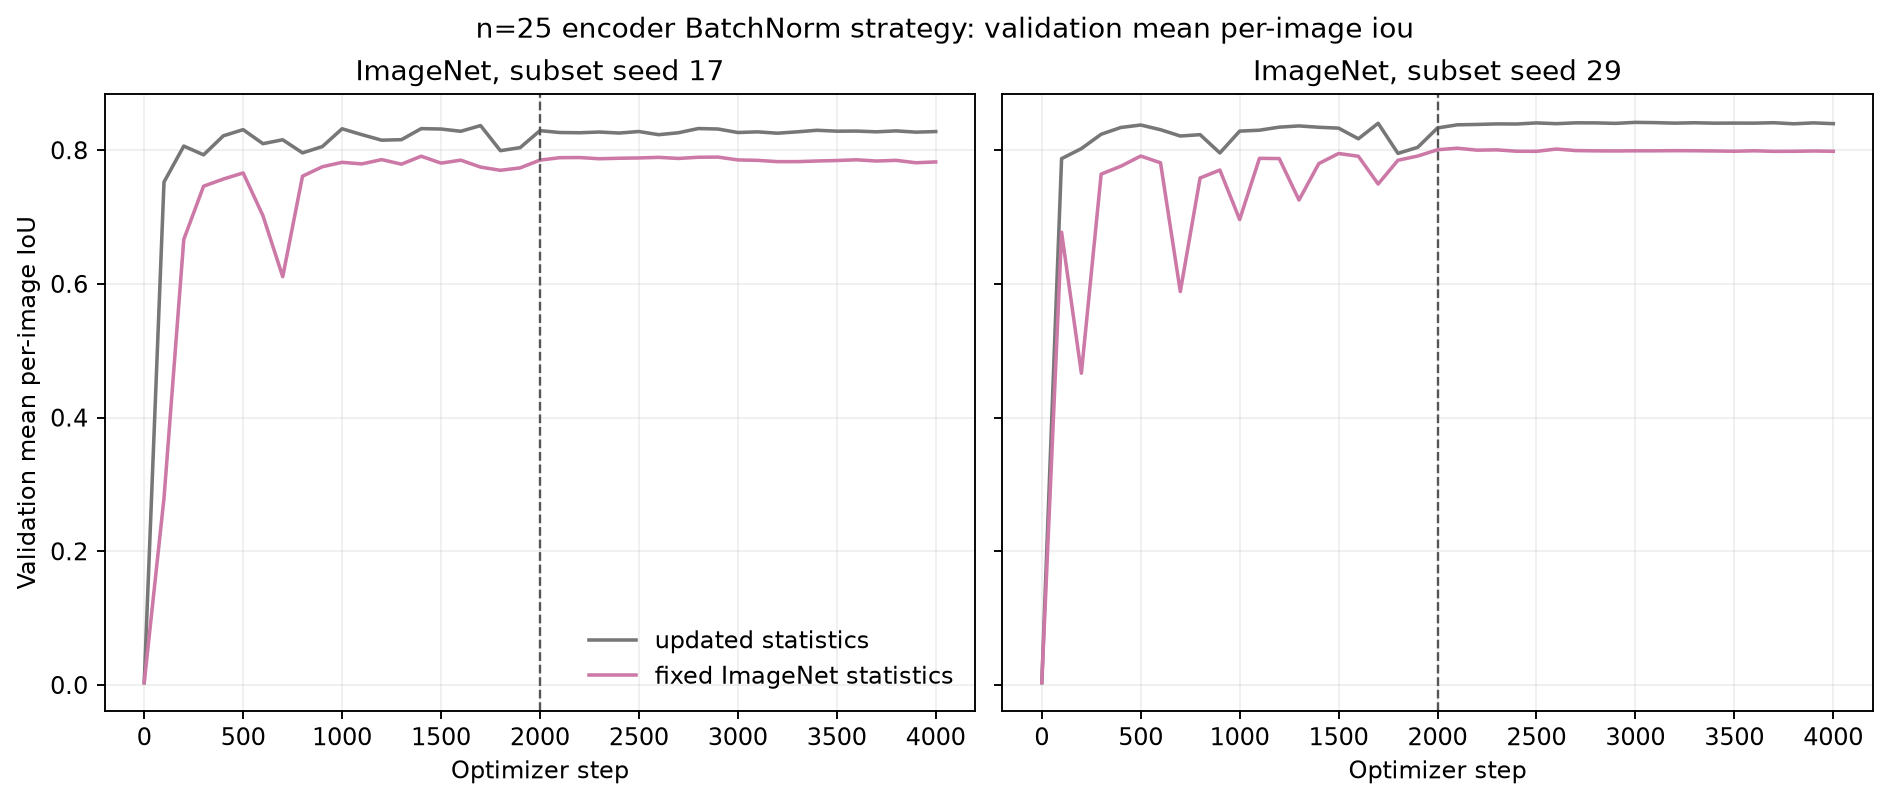

In [20]:
display(Image(filename=ROOT / 'reports/figures/encoder_batch_norm_n25_iou.png'))


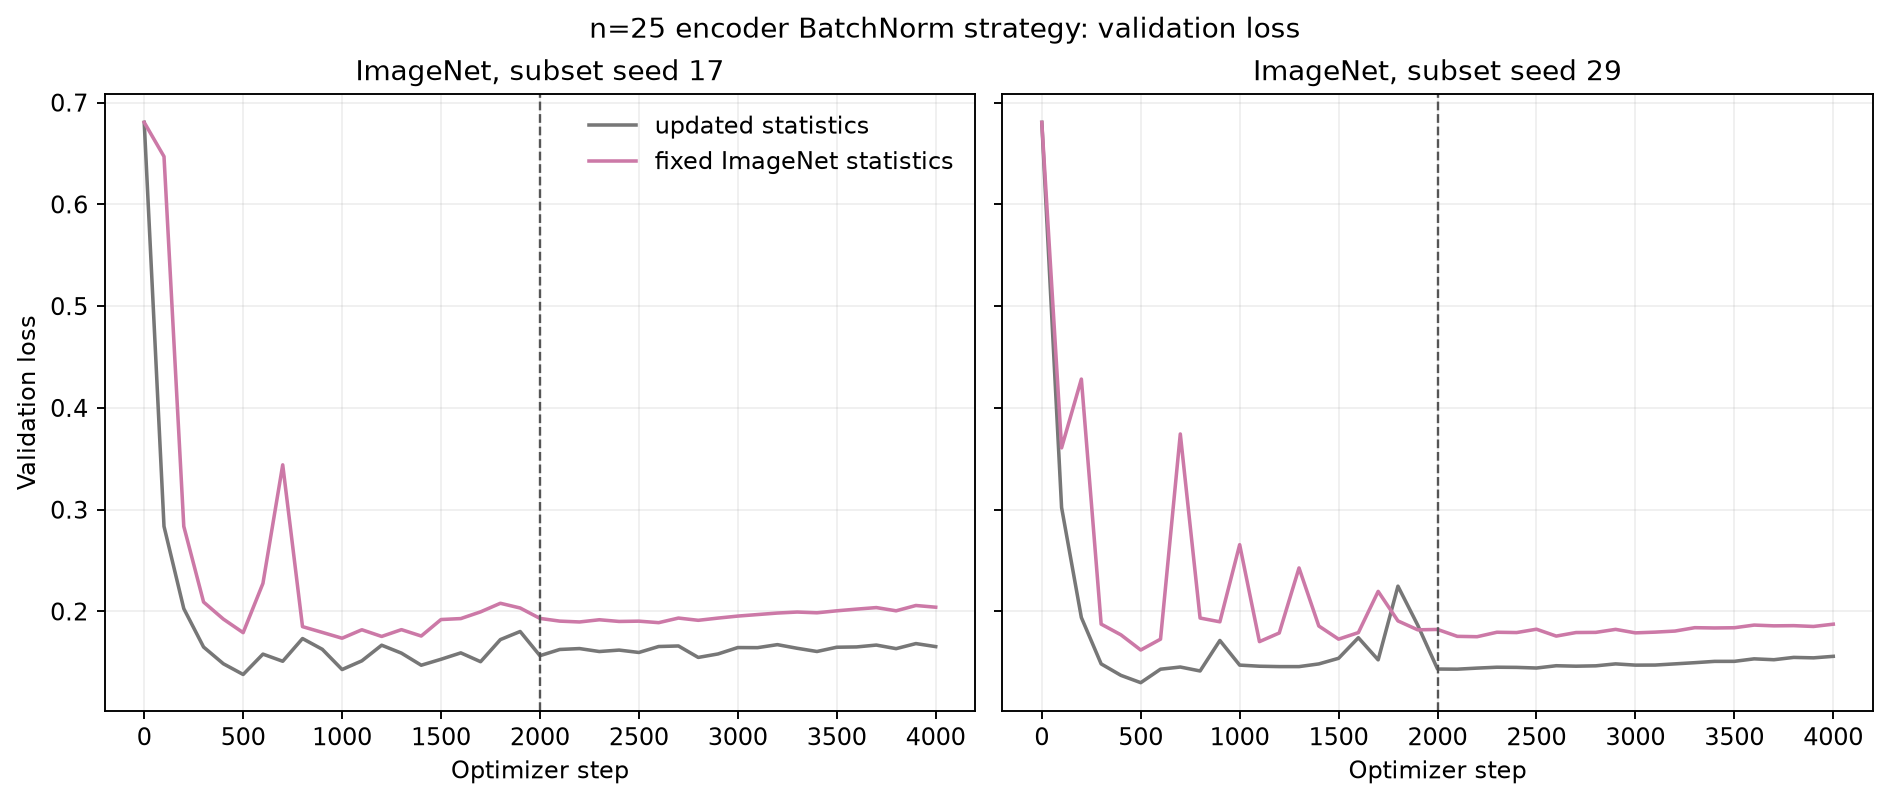

In [21]:
display(Image(filename=ROOT / 'reports/figures/encoder_batch_norm_n25_loss.png'))


In [22]:
bn_late_columns = {
    'subset_seed': 'seed',
    'frozen_encoder_statistics': 'fixed ImageNet statistics',
    'iou_trend_per_1000': 'IoU trend / 1,000',
    'iou_residual_sd': 'IoU residual SD',
    'loss_trend_per_1000': 'loss trend / 1,000',
    'loss_residual_sd': 'loss residual SD',
}
display(BN_RESULTS[list(bn_late_columns)].rename(columns=bn_late_columns).style.format({
    'IoU trend / 1,000': '{:+.4f}', 'IoU residual SD': '{:.4f}',
    'loss trend / 1,000': '{:+.4f}', 'loss residual SD': '{:.4f}',
}))


,seed,fixed ImageNet statistics,"IoU trend / 1,000",IoU residual SD,"loss trend / 1,000",loss residual SD
0,17,False,+0.0010,0.0020,+0.0025,0.0029
1,17,True,-0.0037,0.0015,+0.0088,0.0016
2,29,False,+0.0008,0.0008,+0.0063,0.0009
3,29,True,-0.0012,0.0009,+0.0056,0.0017


Both fixed-statistics runs show large early fluctuations, settle below their references after the learning-rate reduction and then drift slightly downward in IoU. Their late IoU residual variation is small, but this reflects a stable lower trajectory rather than better performance. Validation loss rises late for both strategies; the increase is steeper with fixed statistics for Seed 17 and remains positive for Seed 29.


## 17. Comparable training fit, limitations and decision

Training and validation metrics below are recomputed without augmentation in evaluation mode at the selected checkpoint. They therefore support a like-for-like gap comparison.


In [23]:
bn_comparison_columns = {
    'subset_seed': 'seed',
    'frozen_encoder_statistics': 'fixed ImageNet statistics',
    'selected_training_loss': 'train loss',
    'selected_validation_loss': 'validation loss',
    'selected_training_iou': 'train IoU',
    'best_validation_iou': 'validation IoU',
    'training_minus_validation_iou': 'IoU gap',
    'selected_training_dice': 'train Dice',
    'selected_validation_dice': 'validation Dice',
    'selected_training_ap': 'train AP',
    'selected_validation_ap': 'validation AP',
}
display(BN_RESULTS[list(bn_comparison_columns)].rename(columns=bn_comparison_columns).style.format({
    column: '{:.3f}' for column in list(bn_comparison_columns.values())[2:]
}))


,seed,fixed ImageNet statistics,train loss,validation loss,train IoU,validation IoU,IoU gap,train Dice,validation Dice,train AP,validation AP
0,17,False,0.020,0.151,0.967,0.837,0.130,0.983,0.906,0.999,0.948
1,17,True,0.035,0.176,0.941,0.791,0.151,0.970,0.876,0.996,0.936
2,29,False,0.017,0.147,0.972,0.842,0.130,0.986,0.908,0.999,0.959
3,29,True,0.021,0.176,0.965,0.803,0.162,0.982,0.883,0.999,0.937


The comparable train–validation IoU gap grows by +0.0206 for Seed 17 and +0.0321 for Seed 29. Fixed ImageNet statistics therefore neither improve validation performance nor reduce the diagnosed separation. One plausible interpretation is that natural-image running statistics are poorly matched to these normalized aerial images and that adaptation is useful; the experiment observes the performance consequence but does not directly identify the causal distribution mismatch.

This block varies one fine-tuning strategy for pretrained models. The two 25-image subsets share four IDs, all other random seeds are fixed, and both runs use the same repeatedly inspected validation region. The result does not measure full training variance, establish significance or demonstrate geographic generalization. It also does not show that BatchNorm caused the colour-augmentation result. The locked test region remained absent from training, selection and qualitative inspection.

Fixed encoder BatchNorm statistics should not be adopted. A focused next block could test `Dropout2d(p=0.1)` at one predeclared decoder location for both initializations and both subset selections, paired against the existing D4-only references. This would target the persistent small-data fit gap without preserving potentially mismatched ImageNet statistics. No dropout experiment is run here.


## 18. Overall conclusion

Neither stronger weight decay nor fixed ImageNet BatchNorm statistics improves the n=25 common recipe. Mild brightness/contrast remains a small Random-only candidate, while ImageNet performs best with ordinary encoder BatchNorm adaptation. The D4-only, `weight_decay=1e-4` recipe with updated BatchNorm statistics remains the supported shared baseline for subsequent targeted comparisons.
